In [6]:
#Dataset Creation
import pandas as pd
import numpy as np

np.random.seed(42)
n = 10000

# -- ACQUISITION ----------------------------
channel = np.random.choice(
    ['App Organic', 'Referral', 'Agent', 'Partnership'],
    n, p=[0.40, 0.25, 0.20, 0.15])

# -- CUSTOMER PROFILE -----------------------
age = np.random.randint(21, 58, n)
city_tier = np.random.choice([1, 2, 3], n, p=[0.30, 0.40, 0.30])
employment_type = np.random.choice(
    ['Salaried', 'Self-Employed', 'Informal', 'Student'],
    n, p=[0.45, 0.25, 0.20, 0.10])

income_map = {
    'Salaried':      (45000, 15000),
    'Self-Employed': (38000, 18000),
    'Informal':      (18000, 6000),
    'Student':       (8000,  3000)}
monthly_income = np.array([
    max(5000, np.random.normal(income_map[e][0], income_map[e][1]))
    for e in employment_type])

has_credit_history = np.random.choice([1, 0], n, p=[0.65, 0.35])

fico_score = np.where(
    has_credit_history == 1,
    np.clip(np.random.normal(685, 45, n), 580, 850),
    np.nan)

# -- LOAN & PRODUCT ---------------------------
loan_purpose = np.random.choice(
    ['Personal', 'BNPL', 'Working Capital', 'Education', 'Medical'],
    n, p=[0.30, 0.25, 0.20, 0.15, 0.10])

loan_amount = np.clip(
    np.random.normal(75000, 40000, n), 5000, 500000)

tenure_months = np.random.choice([3, 6, 12, 18, 24, 36], n)

# -- GRADE based on FICO + income ----------------------
def assign_grade(fico, income):
    if np.isnan(fico):
        return 'D' if income > 30000 else 'E'
    if fico >= 760: return 'A'
    if fico >= 730: return 'B'
    if fico >= 700: return 'C'
    if fico >= 665: return 'D'
    if fico >= 635: return 'E'
    if fico >= 605: return 'F'
    return 'G'

grade = np.array([assign_grade(f, i)
                  for f, i in zip(fico_score, monthly_income)])

grade_rate_map = {
    'A': 0.11, 'B': 0.14, 'C': 0.18,
    'D': 0.23, 'E': 0.28, 'F': 0.33, 'G': 0.38}
interest_rate = np.array([
    grade_rate_map[g] + np.random.normal(0, 0.005)
    for g in grade])

monthly_installment = (loan_amount * interest_rate/12) / (
    1 - (1 + interest_rate/12)**(-tenure_months))

dti = np.clip(
    (monthly_installment / monthly_income) +
    np.random.normal(0.20, 0.08, n), 0.05, 1.0)

installment_to_income = np.clip(
    monthly_installment / monthly_income, 0.01, 0.95)

# -- BEHAVIOURAL SIGNALS --------------------------
cash_flow_volatility = np.random.uniform(0, 1, n)
spending_shock = np.random.choice([0, 1], n, p=[0.80, 0.20])

# -- DEFAULT PROBABILITY — grade-driven -----------------------
grade_base = {
    'A': 0.05, 'B': 0.10, 'C': 0.20,
    'D': 0.32, 'E': 0.42, 'F': 0.52, 'G': 0.60}

default_prob = np.array([grade_base[g] for g in grade])

# Modifiers
default_prob += 0.08 * (dti > 0.5)
default_prob += 0.06 * (installment_to_income > 0.35)
default_prob += 0.07 * (employment_type == 'Informal')
default_prob += 0.05 * (employment_type == 'Student')
default_prob += 0.06 * (has_credit_history == 0)
default_prob += 0.05 * (cash_flow_volatility > 0.75)
default_prob += 0.06 * spending_shock
default_prob += 0.04 * (city_tier == 3)
default_prob += 0.05 * (channel == 'Agent')
default_prob -= 0.06 * (employment_type == 'Salaried')
default_prob -= 0.04 * (channel == 'Referral')

default_prob = np.clip(default_prob, 0.02, 0.95)
default = (np.random.uniform(0, 1, n) < default_prob).astype(int)

days_delinquent = np.where(
    default == 1, np.random.randint(30, 180, n), 0)
partial_payment = np.where(
    default == 1, np.random.uniform(0, 0.8, n), 1.0)

# --- BUILD DATAFRAME -----------------------------------
df = pd.DataFrame({
    'customer_id':            [f'CUST{str(i).zfill(5)}' for i in range(n)],
    'age':                    age,
    'city_tier':              city_tier,
    'employment_type':        employment_type,
    'monthly_income':         monthly_income.round(0),
    'has_credit_history':     has_credit_history,
    'fico_score':             fico_score,
    'acquisition_channel':    channel,
    'loan_purpose':           loan_purpose,
    'loan_amount':            loan_amount.round(0),
    'tenure_months':          tenure_months,
    'interest_rate':          (interest_rate * 100).round(2),
    'monthly_installment':    monthly_installment.round(0),
    'grade':                  grade,
    'dti':                    dti.round(4),
    'installment_to_income':  installment_to_income.round(4),
    'cash_flow_volatility':   cash_flow_volatility.round(4),
    'spending_shock':         spending_shock,
    'days_delinquent':        days_delinquent,
    'partial_payment_ratio':  partial_payment.round(4),
    'default':                default
})

df.to_csv('digital_lending_synthetic.csv', index=False)

print("Dataset created!")
print("Shape:", df.shape)
print("\nOverall default rate:", round(df['default'].mean()*100, 2), "%")
print("\nDefault rate by Grade:")
print((df.groupby('grade')['default'].mean()*100).round(1))
print("\nDefault rate by Channel:")
print((df.groupby('acquisition_channel')['default'].mean()*100).round(1))
print("\nDefault rate by Employment:")
print((df.groupby('employment_type')['default'].mean()*100).round(1))
print("\nNTC customers:", (df['has_credit_history']==0).sum())

Dataset created!
Shape: (10000, 21)

Overall default rate: 42.51 %

Default rate by Grade:
grade
A    14.0
B    17.6
C    26.8
D    40.6
E    57.0
F    60.4
G    62.1
Name: default, dtype: float64

Default rate by Channel:
acquisition_channel
Agent          47.7
App Organic    41.9
Partnership    43.1
Referral       39.2
Name: default, dtype: float64

Default rate by Employment:
employment_type
Informal         55.0
Salaried         34.6
Self-Employed    42.6
Student          53.7
Name: default, dtype: float64

NTC customers: 3488


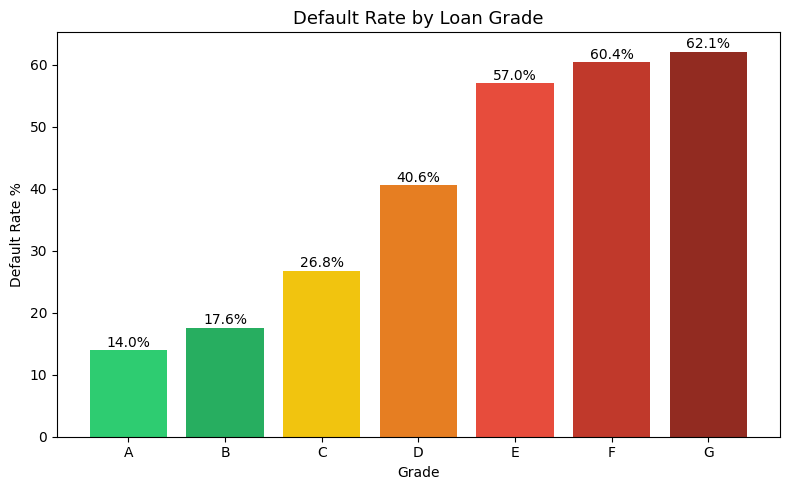

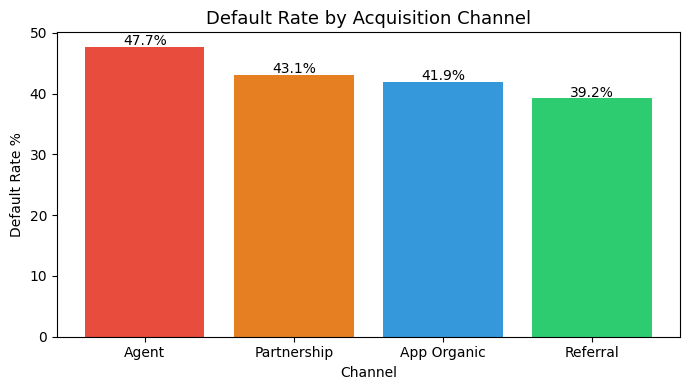

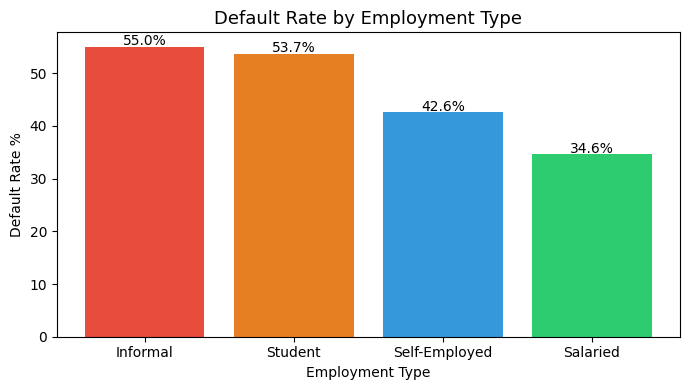


GAP ANALYSIS:
                       Fully Paid  Defaulted
dti                          0.47       0.58
fico_score                 695.70     669.07
installment_to_income        0.29       0.40
monthly_income           36794.19   30934.72
loan_amount              73668.12   78000.33
interest_rate               22.29      25.51

Logistic Regression AUC: 0.6985
XGBoost AUC:             0.6933


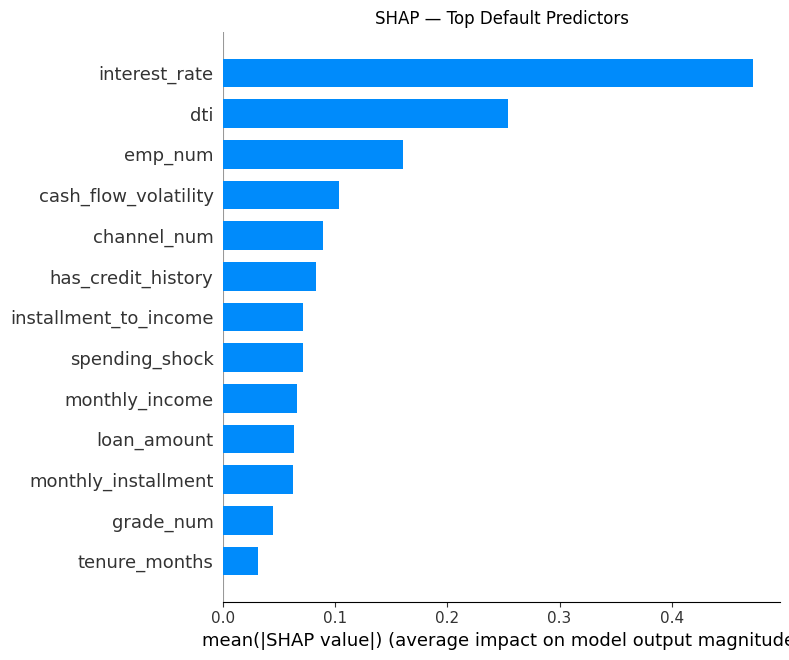


All plots saved!
plot1_grade_default.png
plot2_channel_default.png
plot3_employment_default.png
plot4_shap.png


In [7]:
# -------------Full EDA + Model --------------------------
# --- MODELLING ----------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('digital_lending_synthetic.csv')

# -------- PLOT 1: Default rate by Grade -------------------
grade_stats = df.groupby('grade').agg(
    total=('default','count'),
    defaults=('default','sum')
).reset_index()
grade_stats['default_rate'] = (
    grade_stats['defaults']/grade_stats['total']*100).round(1)

plt.figure(figsize=(8,5))
bars = plt.bar(grade_stats['grade'],
               grade_stats['default_rate'],
               color=['#2ecc71','#27ae60','#f1c40f',
                      '#e67e22','#e74c3c','#c0392b','#922b21'])
for bar, val in zip(bars, grade_stats['default_rate']):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.5,
             f'{val}%', ha='center', fontsize=10)
plt.title('Default Rate by Loan Grade', fontsize=13)
plt.xlabel('Grade')
plt.ylabel('Default Rate %')
plt.tight_layout()
plt.savefig('plot1_grade_default.png', dpi=150)
plt.show()

# -- PLOT 2: Default rate by Channel ----------------------------
channel_stats = (df.groupby('acquisition_channel')['default']
                 .mean()*100).round(1).sort_values(ascending=False)

plt.figure(figsize=(7,4))
bars2 = plt.bar(channel_stats.index, channel_stats.values,
                color=['#e74c3c','#e67e22','#3498db','#2ecc71'])
for bar, val in zip(bars2, channel_stats.values):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.3,
             f'{val}%', ha='center', fontsize=10)
plt.title('Default Rate by Acquisition Channel', fontsize=13)
plt.xlabel('Channel')
plt.ylabel('Default Rate %')
plt.tight_layout()
plt.savefig('plot2_channel_default.png', dpi=150)
plt.show()

# -- PLOT 3: Default rate by Employment ------------------------------
emp_stats = (df.groupby('employment_type')['default']
             .mean()*100).round(1).sort_values(ascending=False)

plt.figure(figsize=(7,4))
bars3 = plt.bar(emp_stats.index, emp_stats.values,
                color=['#e74c3c','#e67e22','#3498db','#2ecc71'])
for bar, val in zip(bars3, emp_stats.values):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.3,
             f'{val}%', ha='center', fontsize=10)
plt.title('Default Rate by Employment Type', fontsize=13)
plt.xlabel('Employment Type')
plt.ylabel('Default Rate %')
plt.tight_layout()
plt.savefig('plot3_employment_default.png', dpi=150)
plt.show()

# -- PLOT 4: Gap Analysis Table ---------------------------
gap = df.groupby('default')[
    ['dti','fico_score','installment_to_income',
     'monthly_income','loan_amount','interest_rate']
].mean().round(2)
gap.index = ['Fully Paid','Defaulted']
print("\nGAP ANALYSIS:")
print(gap.T)

# -- MODELLING -----------------------------------------------
df_model = df.copy()
df_model['grade_num'] = df_model['grade'].map(
    {'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})
df_model['channel_num'] = df_model['acquisition_channel'].map(
    {'Referral':1,'App Organic':2,'Partnership':3,'Agent':4})
df_model['emp_num'] = df_model['employment_type'].map(
    {'Salaried':1,'Self-Employed':2,'Informal':3,'Student':4})

features = ['loan_amount','interest_rate','monthly_installment',
            'grade_num','monthly_income','dti',
            'installment_to_income','cash_flow_volatility',
            'spending_shock','has_credit_history',
            'channel_num','emp_num','tenure_months']

model_df = df_model[features+['default']].dropna()
X = model_df.drop('default', axis=1)
y = model_df['default']

X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Logistic Regression
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xte_s = scaler.transform(X_test)
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(Xtr_s, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(Xte_s)[:,1])

# XGBoost
xgb = XGBClassifier(n_estimators=100, max_depth=4,
                     learning_rate=0.1, scale_pos_weight=2,
                     random_state=42, eval_metric='auc',
                     verbosity=0)
xgb.fit(X_train, y_train)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

print(f"\nLogistic Regression AUC: {lr_auc:.4f}")
print(f"XGBoost AUC:             {xgb_auc:.4f}")

# -- SHAP ------------------------------------------
sample = X_test.sample(1000, random_state=42)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(sample)

plt.figure()
shap.summary_plot(shap_values, sample,
                  plot_type="bar", show=False)
plt.title("SHAP — Top Default Predictors")
plt.tight_layout()
plt.savefig('plot4_shap.png', dpi=150)
plt.show()

print("\nAll plots saved!")
print("plot1_grade_default.png")
print("plot2_channel_default.png")
print("plot3_employment_default.png")
print("plot4_shap.png")

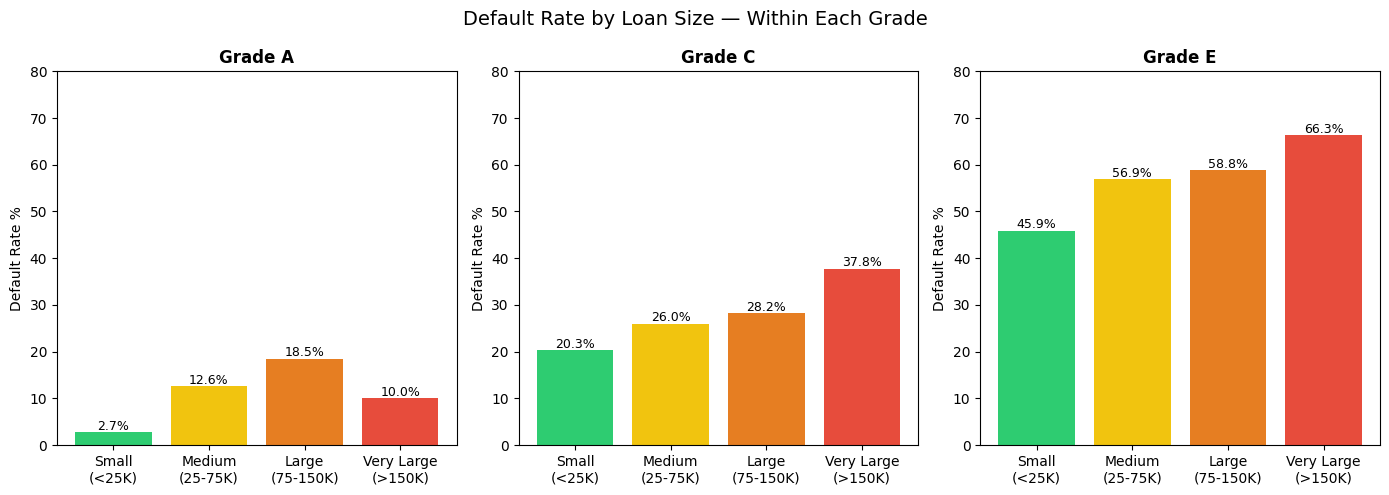

Plot 5 saved!


In [8]:
# -- ANALYSIS 1: Loan Amount Buckets vs Default Rate by Grade -------------
df['loan_bucket'] = pd.cut(df['loan_amount'],
                            bins=[0, 25000, 75000, 150000, 500000],
                            labels=['Small\n(<25K)', 'Medium\n(25-75K)',
                                    'Large\n(75-150K)', 'Very Large\n(>150K)'])

pivot = df.groupby(['grade', 'loan_bucket'])['default'].mean() * 100
pivot = pivot.reset_index()
pivot.columns = ['grade', 'loan_bucket', 'default_rate']

# Plot only top grades for clarity
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, grade in zip(axes, ['A', 'C', 'E']):
    subset = pivot[pivot['grade'] == grade]
    bars = ax.bar(subset['loan_bucket'], subset['default_rate'],
                  color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
    for bar, val in zip(bars, subset['default_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9)
    ax.set_title(f'Grade {grade}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Default Rate %')
    ax.set_ylim(0, 80)

fig.suptitle('Default Rate by Loan Size — Within Each Grade', fontsize=14)
plt.tight_layout()
plt.savefig('plot5_loan_amount_grade.png', dpi=150)
plt.show()
print("Plot 5 saved!")

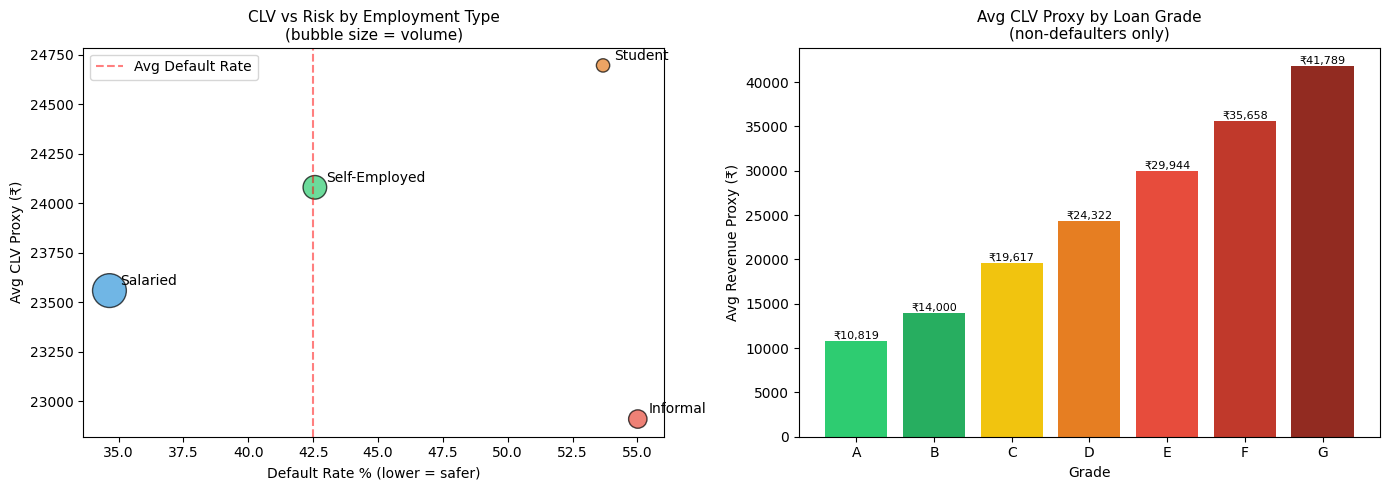


── CLV SUMMARY TABLE ──

By Employment Type:
      Segment  Avg CLV (₹)  Default Rate (%)  Volume
     Informal      22911.0              55.0     879
     Salaried      23559.0              34.6    2965
Self-Employed      24080.0              42.6    1445
      Student      24695.0              53.7     460

By Grade:
grade  avg_clv  count
    A  10819.0    282
    B  14000.0    627
    C  19617.0   1012
    D  24322.0   2263
    E  29944.0   1227
    F  35658.0    235
    G  41789.0    103

Plot 6 saved!


In [9]:
# -- ANALYSIS 2: CLV Proxy for Non-Defaulters ---------------------------
good = df[df['default'] == 0].copy()

# Revenue estimate: loan_amount × (interest_rate/100) × (tenure_months/12)
good['clv_proxy'] = (good['loan_amount'] *
                     (good['interest_rate'] / 100) *
                     (good['tenure_months'] / 12))

# Average CLV and volume by employment type
clv_emp = good.groupby('employment_type').agg(
    avg_clv=('clv_proxy', 'mean'),
    count=('clv_proxy', 'count')
).round(0).reset_index()

# Average CLV by grade
clv_grade = good.groupby('grade').agg(
    avg_clv=('clv_proxy', 'mean'),
    count=('clv_proxy', 'count')
).round(0).reset_index()

# Also get default rate per segment for the "low risk" axis
dr_emp = df.groupby('employment_type')['default'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: CLV by Employment (bubble size = volume)
colors_emp = ['#e74c3c', '#3498db', '#2ecc71', '#e67e22']
scatter = axes[0].scatter(dr_emp.values, clv_emp['avg_clv'],
                           s=clv_emp['count'] / 5,
                           c=colors_emp, alpha=0.7, edgecolors='black')
for i, row in clv_emp.iterrows():
    axes[0].annotate(row['employment_type'],
                     (dr_emp[row['employment_type']], row['avg_clv']),
                     textcoords="offset points", xytext=(8, 4), fontsize=10)
axes[0].axvline(x=42.5, color='red', linestyle='--', alpha=0.5, label='Avg Default Rate')
axes[0].set_xlabel('Default Rate % (lower = safer)')
axes[0].set_ylabel('Avg CLV Proxy (₹)')
axes[0].set_title('CLV vs Risk by Employment Type\n(bubble size = volume)', fontsize=11)
axes[0].legend()

# Plot B: CLV by Grade
axes[1].bar(clv_grade['grade'], clv_grade['avg_clv'],
            color=['#2ecc71','#27ae60','#f1c40f','#e67e22','#e74c3c','#c0392b','#922b21'])
for i, row in clv_grade.iterrows():
    axes[1].text(i, row['avg_clv'] + 200, f"₹{row['avg_clv']:,.0f}",
                 ha='center', fontsize=8)
axes[1].set_title('Avg CLV Proxy by Loan Grade\n(non-defaulters only)', fontsize=11)
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Avg Revenue Proxy (₹)')

plt.tight_layout()
plt.savefig('plot6_clv_analysis.png', dpi=150)
plt.show()

# Print summary table
print("\n── CLV SUMMARY TABLE ──")
print("\nBy Employment Type:")
summary = clv_emp.copy()
summary['default_rate'] = dr_emp.values.round(1)
summary = summary[['employment_type', 'avg_clv', 'default_rate', 'count']]
summary.columns = ['Segment', 'Avg CLV (₹)', 'Default Rate (%)', 'Volume']
print(summary.to_string(index=False))
print("\nBy Grade:")
print(clv_grade[['grade','avg_clv','count']].to_string(index=False))
print("\nPlot 6 saved!")

In [10]:
# -- EXPECTED REVENUE ANALYSIS (after default losses) -----------------
import pandas as pd
df = pd.read_csv('digital_lending_synthetic.csv')

grade_summary = df.groupby('grade').agg(
    total=('default', 'count'),
    default_rate=('default', 'mean'),
    avg_clv=('clv_proxy', 'mean') if 'clv_proxy' in df.columns
             else ('loan_amount', 'mean')
).reset_index()

# Recompute CLV on full df first
df['clv_proxy'] = (
    df['loan_amount'] *
    (df['interest_rate'] / 100) *
    (df['tenure_months'] / 12)
)

grade_revenue = df.groupby('grade').agg(
    count=('default', 'count'),
    default_rate=('default', 'mean'),
    avg_clv=('clv_proxy', 'mean')
).reset_index()

grade_revenue['expected_revenue'] = (
    grade_revenue['avg_clv'] * (1 - grade_revenue['default_rate'])
).round(0)

grade_revenue['default_rate'] = (grade_revenue['default_rate'] * 100).round(1)
grade_revenue['avg_clv'] = grade_revenue['avg_clv'].round(0)

print("── EXPECTED REVENUE PER LOAN (after default risk) ──")
print(grade_revenue[['grade','default_rate','avg_clv',
                      'expected_revenue','count']].to_string(index=False))

── EXPECTED REVENUE PER LOAN (after default risk) ──
grade  default_rate  avg_clv  expected_revenue  count
    A          14.0  10523.0            9047.0    328
    B          17.6  13853.0           11414.0    761
    C          26.8  19343.0           14154.0   1383
    D          40.6  23388.0           13902.0   3807
    E          57.0  29396.0           12629.0   2856
    F          60.4  35915.0           14233.0    593
    G          62.1  39259.0           14867.0    272


In [11]:
import pandas as pd

# Re-save the dataframe to disk first
df.to_csv('digital_lending_synthetic.csv', index=False)
print("Saved! Rows:", len(df), "| Columns:", df.shape[1])

Saved! Rows: 10000 | Columns: 22


In [12]:
from google.colab import files

# Download the synthetic dataset
files.download('digital_lending_synthetic.csv')

print("CSV downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV downloaded!
